In [1]:
import logomaker
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
import glob
results_file = glob.glob('/clusterfs/nilah/sergio/RFdifussion/outputs/*/*.csv')
print(len(results_file))

955


In [3]:
import pandas as pd
import os

def aggregate_results(results_files, run_id_level=-2, extra_columns=None):
    """
    Aggregate CSV files into a single DataFrame with run identifiers.
    
    Args:
        results_files (list): List of paths to CSV files.
        run_id_level (int): Directory level to extract run ID (e.g., -2 for parent of filename).
        extra_columns (dict): Optional dictionary of column_name: lambda_function to add metadata.
    
    Returns:
        pd.DataFrame: Concatenated DataFrame with run IDs and optional columns.
    """
    if not results_files:
        print("Warning: No files provided.")
        return pd.DataFrame()

    dfs = []
    for file_path in results_files:
        # try:
        # Read CSV
        tmp = pd.read_csv(file_path)
        
        # Extract run ID from path
        run_id = os.path.split(os.path.dirname(file_path))[run_id_level]
        tmp['RUN'] = run_id
        
        # Add optional columns
        # if extra_columns:
        #     for col_name, func in extra_columns.items():
        #         tmp[col_name] = func(file_path)
        
        dfs.append(tmp)
        # print(f"Processed: {file_path}")

    # Concatenate all DataFrames
    if dfs:
        results = pd.concat(dfs, axis=0 )# , ignore_index=True)
        print(f"Aggregated {len(dfs)} files into DataFrame with {len(results)} rows.")
        return results
    else:
        print("No valid files processed.")
        return pd.DataFrame()

# Example usage for RFdiffusion results
# results_dir = "/clusterfs/nilah/sergio/RFdifussion/outputs/EPITOPE_SERIES_20250416/*/af2.csv"
results_files = glob.glob('/clusterfs/nilah/sergio/RFdifussion/outputs/*/*.csv')

# # Define extra columns (e.g., extract contigs, iterations, num_seqs from run name)
# extra_columns = {
#     'contigs': lambda x: x.split('/')[-3].split('_C')[1].split('_I')[0],
#     'iterations': lambda x: x.split('_I')[1].split('_NS')[0],
#     'num_seqs': lambda x: x.split('_NS')[1].split('_')[0]
# }

# Aggregate results
results = aggregate_results(results_files, run_id_level=-2) #, extra_columns=extra_columns)

Aggregated 955 files into DataFrame with 30560 rows.


array([[<Axes: title={'center': 'plddt'}>]], dtype=object)

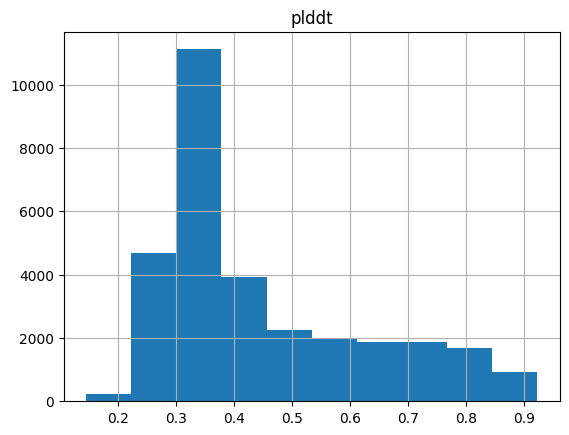

In [4]:
results.hist('plddt')

array([[<Axes: title={'center': 'rmsd'}>]], dtype=object)

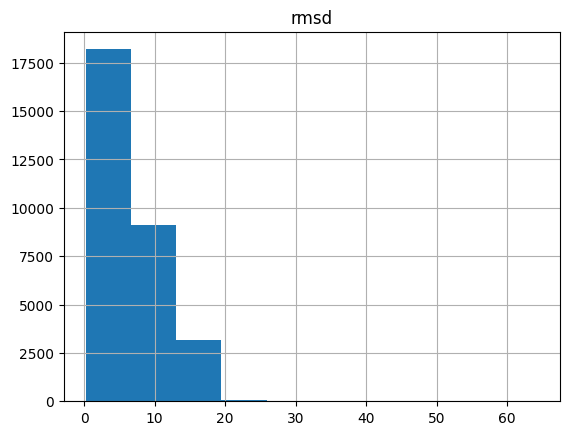

In [5]:
results.hist('rmsd')

array([[<Axes: title={'center': 'i_ptm'}>]], dtype=object)

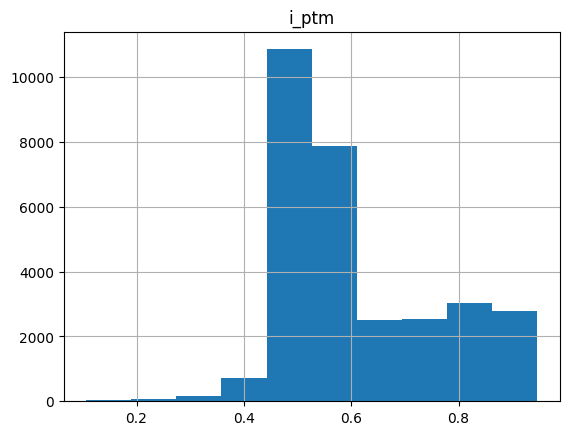

In [6]:
results.hist('i_ptm')

array([[<Axes: title={'center': 'i_pae'}>]], dtype=object)

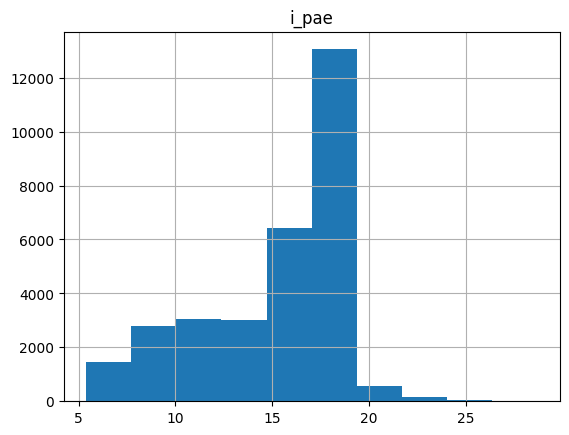

In [7]:
results.hist('i_pae')

In [8]:
# # Filter top sequences by structural confidence
# filtered = results[
#     (results['plddt'] > 0.8) &
#     (results['ptm'] > 0.05) &
#     (results['pae'] < 5.0) &
#     (results['rmsd'] < 2.0)
# ].sort_values(by='plddt', ascending=False)

# print(filtered[['seq', 'plddt', 'ptm', 'pae', 'rmsd', 'mpnn']].head(10))


In [9]:
results['epitope'] = results['seq'].apply(lambda x: x.split("/")[1])
results['length'] = results['epitope'].apply(lambda x: len(x))

In [10]:
results.sort_values(by='plddt', ascending=False)

,Unnamed: 0,design,n,mpnn,plddt,i_ptm,i_pae,rmsd,seq,RUN,epitope,length
0,0,0,0,1.339388,0.922469,0.939850,5.715950,14.813799,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,SQAPVVAI,8
2,2,0,2,1.330234,0.922469,0.939850,5.715950,14.813799,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,SQAPVVAI,8
9,9,0,9,1.332616,0.922469,0.939850,5.715950,14.813799,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,SQAPVVAI,8
26,26,0,26,1.295440,0.922469,0.939850,5.715950,14.813799,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,SQAPVVAI,8
18,18,0,18,0.697885,0.918757,0.946168,5.704641,0.819085,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,SSLPPVIPAA,10
...,...,...,...,...,...,...,...,...,...,...,...,...
29,29,0,29,1.252044,0.147783,0.153149,25.900809,15.124124,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,SRELTVVE,8
17,17,0,17,1.179920,0.147783,0.153149,25.900809,15.124124,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,SRELTVVE,8
2,2,0,2,1.213150,0.147783,0.153149,25.900809,15.124124,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,SRELTVVE,8
30,30,0,30,1.252247,0.147783,0.153149,25.900809,15.124124,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,SRELTVVE,8


In [11]:
results = results.drop_duplicates('epitope')

In [12]:
import seaborn as sns

<Axes: xlabel='length', ylabel='plddt'>

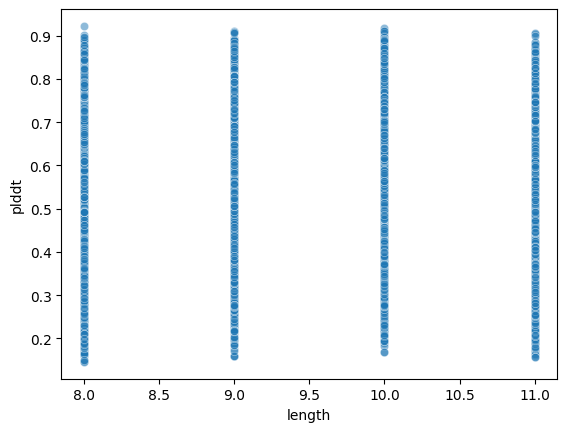

In [13]:
sns.scatterplot(data=results, x='length', y='plddt', alpha=0.5)

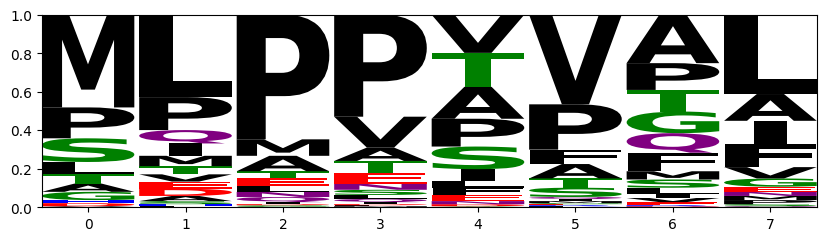

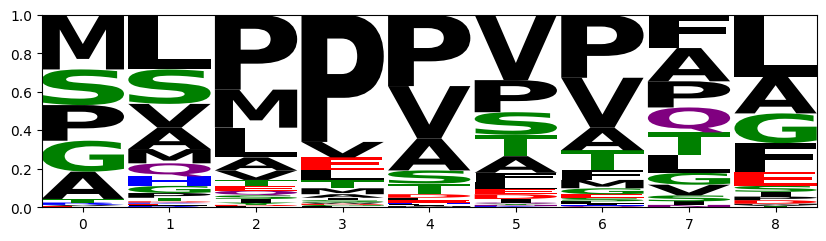

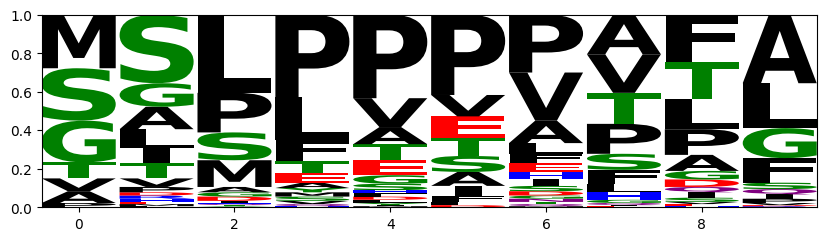

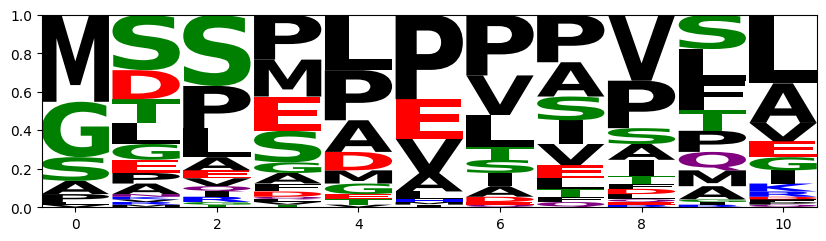

In [14]:
for n in range(8, 12):

    seq_length = n

    sequences = results[(results['epitope'].str.len() == seq_length) & (results['plddt'] > 0.8)]['epitope'].tolist()

    # Create a list of amino acids (standard 20 amino acids)
    amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

    freq_matrix = np.zeros((seq_length, len(amino_acids)))

    # Populate the frequency matrix: count occurrences of each amino acid at each position
    for seq in sequences:
        for i, aa in enumerate(seq):
            aa_index = amino_acids.index(aa)
            freq_matrix[i, aa_index] += 1

    # Normalize the frequency matrix to get probabilities (frequencies sum to 1 at each position)
    freq_matrix = freq_matrix / len(sequences)

    # Create a DataFrame for logomaker
    freq_df = pd.DataFrame(freq_matrix, columns=amino_acids)

    # Generate the sequence logo
    logo = logomaker.Logo(freq_df, color_scheme='chemistry') #, font_name='Arial Rounded MT Bold')


In [15]:
results = results.iloc[:, 1:]

In [16]:
results.to_csv('./HLAA0201_PDB_7RTD_RFdiffusion_sequences.csv', index=False)

Name | What it captures | Threshold (after ≤ 5 Å cutoff) | hotspot = "…", ready to copy
core_hotspot | Only the strongest binding hot‑spots—absolute core you almost never want to mutate. |  ≥ 4 distinct protein contacts | "A66,A70,A159"
high_contact | Core + secondary hubs. Good default when you want to preserve the bulk of the binding energy. |  ≥ 3 contacts | "A66,A70,A73,A77,A97,A147,A159"
medium_contact | Moderately important residues; nice to keep fixed if you want a very native‑like interface. |  = 2 contacts | "A7,A63,A99,A116,A143,A146,A155,A156"
low_contact | Peripheral/edge residues; usually safe to let RFdiffusion mutate for better packing/solubility. |  = 1 contact | "A5,A9,A33,A45,A59,A67,A69,A76,A80,A81,A84,A95,A114,A123,A124,A142,A152,A160,A163,A167,A171"
combo_high_low | Lock the high‑energy core while leaving medium residues flexible (high + low combined). | see above | "A5,A9,A33,A45,A59,A66,A67,A69,A70,A73,A76,A77,A80,A81,A84,A95,A97,A114,A123,A124,A142,A147,A152,A159"
all_contacts | Every chain‑A residue that has ≥ 1 heavy‑atom within 5 Å of chain C (36 total). Use to freeze the entire native interface. |  ≥ 1 contact | "A5,A7,A9,A33,A45,A59,A63,A66,A67,A69,A70,A73,A76,A77,A80,A81,A84,A95,A97,A99,A114,A116,A123,A124,A142,A143,A146,A147,A152,A155,A156,A159,A160,A163,A167,A171"
user_hotspot | Your original 9‑residue list. | (user‑defined) | "A7,A9,A59,A63,A66,A70,A99,A159,A167"

In [17]:
import glob
import os
import pandas as pd

# Base directory
base_dir = '/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK'

# List all files and filter for CSV and XLS
all_files = glob.glob(os.path.join(base_dir, '*'))
data_files = [f for f in all_files if f.lower().endswith(('.csv', '.xls'))]

# Display the list of data files
for f in data_files:
    print(f)

# Read each file into a DataFrame
dfs = {}
for f in data_files:
    name = os.path.basename(f)
    if f.lower().endswith('.csv'):
        dfs[name] = pd.read_csv(f)
    else:  # .xls tab-delimited
        dfs[name] = pd.read_csv(f, sep='\t', header=1)

print("\nLoaded DataFrames:")
for name, df in dfs.items():
    print(f"{name}: {df.shape} rows, {df.shape[1]} columns")


/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/lowbinders_A0201_netmhc.xls
/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/evaluation_A0201HLA-lowbinders_mhcflurry_unique.csv
/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/evaluation_A0201epitope-highbinders_mhcflurry_unique.csv
/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/highbinders_A0201_netmhc.xls
/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/A0201highbinders_mhc_flurry.csv
/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/A0201lowbinders_mhc_flurry.csv
/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/evaluation_A0201epitope-lowbinders_mhcflurry_unique.csv
/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/evaluation_A0201HLA-highbinders_mhcflurry_unique.csv

Loaded DataFrames:
lowbinders_A0201_netmhc.xls: (309, 11) rows, 11 columns
evaluation_A0201HLA-lowbinders_mhcflurry_unique.csv: (71, 2) rows, 2 columns
evaluation_A0201epitope-highbinders_mhcflurry

In [18]:
HLA_athena = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/performances/predictions_20250423.204321.tsv', sep = '\t')
HLA_athena

,pep,len,model_A0201,MSi_A0201,prank.MSi_A0201,best.MSi,best.MSi_allele,assign.MSi_scores,assign.MSi_allele
0,GMLPAPPL,8,panpan,0.775238,1.557303,0.775238,A0201,0.775238,A0201
1,VRESPEVT,8,panpan,0.008188,32.050964,0.008188,A0201,NaN,unknown
2,PTMTPAPP,8,panpan,0.010776,29.219358,0.010776,A0201,NaN,unknown
3,PVSLPAPP,8,panpan,0.053162,15.628531,0.053162,A0201,NaN,unknown
4,SSLIVVPG,8,panpan,0.058255,14.988930,0.058255,A0201,NaN,unknown
...,...,...,...,...,...,...,...,...,...
449,MEVEVHLEEV,10,specific,0.072925,8.994611,0.072925,A0201,NaN,unknown
450,MEVEVHQEES,10,specific,0.001466,40.621932,0.001466,A0201,NaN,unknown
451,KTVIELEFEE,10,specific,0.001355,41.583250,0.001355,A0201,NaN,unknown
452,AAMQIDTEPL,10,specific,0.102611,7.496536,0.102611,A0201,0.102611,A0201


In [19]:
# 1) Extract your four DataFrames from the `dfs` dict:
df_eval_hla = dfs['evaluation_A0201HLA-highbinders_mhcflurry_unique.csv']
df_eval_epi = dfs['evaluation_A0201epitope-highbinders_mhcflurry_unique.csv']
df_mhc      = dfs['A0201highbinders_mhc_flurry.csv']
df_net      = dfs['highbinders_A0201_netmhc.xls']
def_ath = HLA_athena

# 2) Rename the key columns so they all join on “sequence”
df_mhc = df_mhc.rename(columns={
    'peptide': 'sequence',
    'affinity': 'mhcflurry_affinity'
})
df_net = df_net.rename(columns={
    'Peptide': 'sequence',
    'BA_Rank': 'netmhc_rank'
})

# 3) Rename the two prediction columns so they don’t collide
df_hla = df_eval_hla[['sequence','prediction']].rename(
    columns={'prediction': 'pred_hla'}
)
df_epi = df_eval_epi[['sequence','prediction']].rename(
    columns={'prediction': 'pred_epitope'}
)

def_ath = def_ath.rename(columns={
    'pep': 'sequence'
})


# 4) Chain them together in one pipeline
df_merged = (
    df_hla
      .merge(df_epi, on='sequence', how='left')                        # add epitope‐encoded preds
      .merge(df_mhc[['sequence','mhcflurry_affinity']], on='sequence', how='left')
      .merge(df_net[['sequence','netmhc_rank']],          on='sequence', how='left')
      .merge(def_ath[['sequence','prank.MSi_A0201']],          on='sequence', how='left')
)

# 5) Inspect
print(df_merged.shape)
print(df_merged.head())


df_merged['mhcflurry_affinity'] = df_merged['mhcflurry_affinity'].apply(np.log10)
df_merged['netmhc_rank'] = df_merged['netmhc_rank'].apply(np.log10)

# 1) Melt for violin plotting
df_long = df_merged.melt(
    id_vars=['sequence'],
    value_vars=['pred_hla','pred_epitope','mhcflurry_affinity','netmhc_rank'],
    var_name='Model',
    value_name='Value'
)

(623, 6)
     sequence  pred_hla  pred_epitope  mhcflurry_affinity  netmhc_rank  \
0  VRDAVIVQFA  2.204794      4.330856        24125.518176      36.9528   
1  MRDAVIVTFA  2.507825      3.608057        21886.187021      21.1986   
2  VRDSVIVQFA  2.171505      4.341064        21984.331574      39.1542   
3    LPPAVTFA  2.696095      4.035941        26144.886335      19.5832   
4    LPPAVTFA  2.696095      4.035941        26144.886335      19.5832   

   prank.MSi_A0201  
0              NaN  
1              NaN  
2              NaN  
3              NaN  
4              NaN  


In [20]:
# 1) Extract your four DataFrames from the `dfs` dict:
df_eval_hla = dfs['evaluation_A0201HLA-lowbinders_mhcflurry_unique.csv']
df_eval_epi = dfs['evaluation_A0201epitope-lowbinders_mhcflurry_unique.csv']
df_mhc      = dfs['A0201lowbinders_mhc_flurry.csv']
df_net      = dfs['lowbinders_A0201_netmhc.xls']

# 2) Rename the key columns so they all join on “sequence”
df_mhc = df_mhc.rename(columns={
    'peptide': 'sequence',
    'affinity': 'mhcflurry_affinity'
})
df_net = df_net.rename(columns={
    'Peptide': 'sequence',
    'BA_Rank': 'netmhc_rank'
})

# 3) Rename the two prediction columns so they don’t collide
df_hla = df_eval_hla[['sequence','prediction']].rename(
    columns={'prediction': 'pred_hla'}
)
df_epi = df_eval_epi[['sequence','prediction']].rename(
    columns={'prediction': 'pred_epitope'}
)

# 4) Chain them together in one pipeline
df_merged = (
    df_hla
      .merge(df_epi, on='sequence', how='left')                        # add epitope‐encoded preds
      .merge(df_mhc[['sequence','mhcflurry_affinity']], on='sequence', how='left')
      .merge(df_net[['sequence','netmhc_rank']],          on='sequence', how='left')
)

# 5) Inspect
print(df_merged.shape)
print(df_merged.head())

df_merged['mhcflurry_affinity'] = df_merged['mhcflurry_affinity'].apply(np.log10)
df_merged['netmhc_rank'] = df_merged['netmhc_rank'].apply(np.log10)

# 1) Melt for violin plotting
df_long2 = df_merged.melt(
    id_vars=['sequence'],
    value_vars=['pred_hla','pred_epitope','mhcflurry_affinity','netmhc_rank'],
    var_name='Model',
    value_name='Value'
)

(71, 5)
    sequence  pred_hla  pred_epitope  mhcflurry_affinity  netmhc_rank
0   SRELTVVE  2.649552      4.883345        32284.414175      90.6034
1   PRELTIVE  2.586061      4.852436        32445.794123      96.7354
2   SRELTTVE  2.400977      4.919100        32921.068520      93.7225
3   SNELTVVE  2.617024      5.043778        31168.899477      88.1565
4  METADVVAE  3.166265      4.774578        22053.210545      63.3307


In [21]:
df_long['Binders'] = 'Plddt > 0.8'

In [22]:
df_long2['Binders'] = 'Plddt < 0.2'

In [23]:
df_long_plot = pd.concat([df_long, df_long2])

In [24]:
model_map = {
    'pred_hla':            'ESMCBA (HLA)',
    'pred_epitope':        'ESMCBA (Epitope)',
    'mhcflurry_affinity':  'MHCflurry',
    'netmhc_rank':         'NetMHCpan'
}
df_long_plot['Model'] = df_long_plot['Model'].map(model_map)

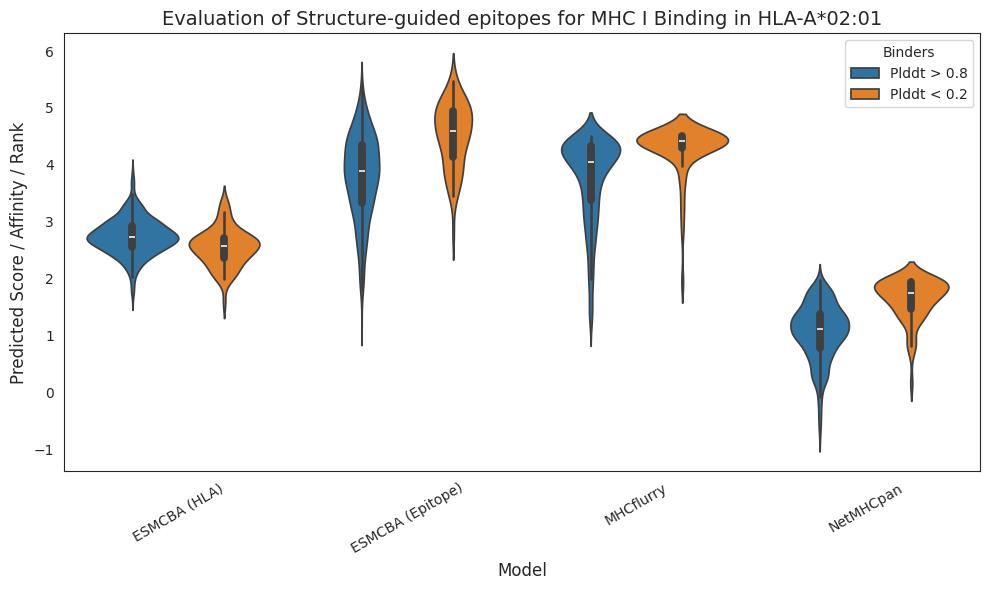

In [25]:


# 3) Seaborn white style & plot
sns.set_style('white')
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(
    x='Model', y='Value',
    data=df_long_plot,
    ax=ax,
    hue='Binders'
)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Predicted Score / Affinity / Rank', fontsize=12)
ax.set_title('Evaluation of Structure-guided epitopes for MHC I Binding in HLA-A*02:01', fontsize=14)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [26]:
print(df_long_plot['sequence'].unique())

['VRDAVIVQFA' 'MRDAVIVTFA' 'VRDSVIVQFA' 'LPPAVTFA' 'LPPSVTFA' 'LPPPVTFA'
 'LPPPFTFA' 'GMLPAPPLI' 'GSLFVTPLPI' 'GMLFVLPLPI' 'GSLFVLPLPI'
 'MLPADIDLSS' 'SLDTAPPTIR' 'VRESPEVTL' 'MESSLPPVPP' 'GESSLPPVPP'
 'PTMTPAPPL' 'PVSLPAPPM' 'DPTNVRFA' 'DPTNVQFA' 'SSLIVVPGP' 'SSLIVVPGA'
 'MPPNVAFA' 'MPPNVTAA' 'MLTFPVSLS' 'GSSMPPVVPPA' 'GSSMPPVLPSA'
 'GSSMPPVIPSV' 'GSSMPPVVPPV' 'GSSMPPVIPPA' 'GSSMPPVIPPV' 'GSSMPPVIPSA'
 'GSSMPPTIPPV' 'GSSMPPTIPSG' 'SSSMPPVVPPV' 'GSSMPPTVPPV' 'GSSMPPVVPSV'
 'GSSMPPTIPPA' 'GSAFGVVVSFA' 'GSAFGVVTSFA' 'GSSLGVVVSFA' 'GSAFGVVTTFA'
 'MVPEPIASF' 'MVPEPIANF' 'MVPEPVASF' 'MSAFEPVHPL' 'MSAFEPVHAL'
 'MTAFGPVHPL' 'MTPFGPVHPL' 'MSPFGPVHPL' 'MSAFEPVHQL' 'GLPPSVAFG'
 'GLPPTVAFG' 'GLPPSVTFG' 'GLPPTVTFG' 'GLPPAVAFG' 'GLPPVVTFG' 'GLPPSVSFG'
 'GLPPSVQFG' 'PLEVPFATL' 'SLLEAADATAL' 'TALPPAVTLA' 'TALPPPVTLA'
 'SALPPAVTIA' 'SALPPPVTLA' 'SGLPPPVTLA' 'TALPPPVTIA' 'SALPPSVTLA'
 'SALPPPVTIA' 'SALPPAVTLA' 'MALPPPVTLA' 'MDPELELEVLL' 'MDPEAELAVLK'
 'MDPELELAVLK' 'MDPEAELAVLR' 'MDPEAELAVLL' 'MDPELELE

In [27]:
import os
import requests

# List of PDB IDs
pdb_ids = """
1HSB,1SYV,1YDP,1ZVS,3HG1,3KPN,3KPO,3KYN,3KYO,3O4L,3OX8,3OXR,3OXS,3TO2,3VFM,3VFN,3VFO,
3VFP,3VFR,3VFS,3VFT,3VFU,3VFV,3VFW,4GKN,4HX1,4JRX,4JRY,4PRA,4PRB,4PRD,4PRE,4PRH,4PRI,
4PRP,5DEG,5NQ1,5NQ3,5VVP,5VWD,5VWF,6BXQ,6GGM,6GH1,6GH4,6GL1,6ID4,6IEX,6J2E,6K7T,6MTL,
6O4Y,6O4Z,6O51,6O53,6P2S,6P64,6TDO,6TDP,6TDQ,6TDR,6TDS,6TMO,6TRN,6TRO,6UJO,6UJQ,6UK2,
6UK4,6UZM,6UZN,6UZO,6UZP,6UZQ,6UZS,6V2O,6VB0,6VB1,6VB2,6VB3,6VB4,6VB5,6VB6,6VB7,6VIU,
6VPZ,6VQ2,6VQD,6VQE,6VQO,6VQY,6VQZ,6VR1,6VR5,6VRM,6VRN,6W51,6XQA,6Y26,6Y28,6Y2A,6Z9V,
6Z9W,6Z9X,7BBG,7CIQ,7CIR,7CIS,7DUU,7DYN,7DZM,7DZN,7EDO,7EJL,7EJM,7EJN,7EU2,7F4W,7JYU,
7JYV,7JYW,7JYX,7K80,7K81,7KGO,7KGP,7KGQ,7KGR,7KGS,7KGT,7LG2,7LG3,7MJ6,7MJ7,7MJ8,7MJ9,
7MKB,7N6D,7N6E,7NMD,7NME,7NMF,7NMG,7OW3,7OW4,7OW5,7OW6,7P3D,7P3E,7PB2,7PBC,7PBE,7PDW,
7Q98,7Q99,7Q9A,7Q9B,7QPJ,7R7V,7R7W,7R7X,7R7Y,7R80,7RE7,7SA2,7SIF,7SIG,7SIH,7SU9,7T0L,
7T5M,7WKJ,7WT3,7WT4,7WT5,7WZZ,7X00,7XF3,7YG3,7ZUC,8CX4,8E13,8E8I,8EC5,8EK5,8EMF,8EMG,
8EMI,8EMJ,8EMK,8EN8,8ENH,8EO8,8ES8,8ES9,8FJA,8FJB,8GOM,8GON,8GVB,8GVG,8GVI,8HN4,8ISN,
8RJ5,8RJH,8RJI,8RNG,8RNH,8ROO,8ROP,8RYN,8RYQ,8SBK,8SBL,8T6M,8V4Z,8WUL,8YIV,8YZR,8YZW,
8YZZ,8Z06,8Z07,8Z08,8ZV9,9BL5,9BL6,9BL9,9BLA,9C96,9GV6,9GV7,9L47,9L48,9L49,9L4A
""".replace("\n", "").split(",")

# Output directory
output_dir = "/clusterfs/nilah/sergio/RFdifussion/structures/pdb_files"
os.makedirs(output_dir, exist_ok=True)

# Download loop
for pdb_id in pdb_ids:
    pdb_id = pdb_id.strip().lower()
    output_file = os.path.join(output_dir, f"{pdb_id}.pdb")
    
    if os.path.exists(output_file):
        print(f"⏭️  Skipping {pdb_id.upper()} (already exists)")
        continue

    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    response = requests.get(url)
    if response.status_code == 200:
        with open(output_file, "w") as f:
            f.write(response.text)
        print(f"✅ Downloaded {pdb_id.upper()}")
    else:
        print(f"❌ Failed to download {pdb_id.upper()}")

print("🏁 Finished downloading all PDBs.")


⏭️  Skipping 1HSB (already exists)
⏭️  Skipping 1SYV (already exists)
⏭️  Skipping 1YDP (already exists)
⏭️  Skipping 1ZVS (already exists)
⏭️  Skipping 3HG1 (already exists)
⏭️  Skipping 3KPN (already exists)
⏭️  Skipping 3KPO (already exists)
⏭️  Skipping 3KYN (already exists)
⏭️  Skipping 3KYO (already exists)
⏭️  Skipping 3O4L (already exists)
⏭️  Skipping 3OX8 (already exists)
⏭️  Skipping 3OXR (already exists)
⏭️  Skipping 3OXS (already exists)
⏭️  Skipping 3TO2 (already exists)
⏭️  Skipping 3VFM (already exists)
⏭️  Skipping 3VFN (already exists)
⏭️  Skipping 3VFO (already exists)
⏭️  Skipping 3VFP (already exists)
⏭️  Skipping 3VFR (already exists)
⏭️  Skipping 3VFS (already exists)
⏭️  Skipping 3VFT (already exists)
⏭️  Skipping 3VFU (already exists)
⏭️  Skipping 3VFV (already exists)
⏭️  Skipping 3VFW (already exists)
⏭️  Skipping 4GKN (already exists)
⏭️  Skipping 4HX1 (already exists)
⏭️  Skipping 4JRX (already exists)
⏭️  Skipping 4JRY (already exists)
⏭️  Skipping 4PRA (a

In [29]:
from Bio.PDB import PDBParser, is_aa
import pandas as pd
import os

# Local directory containing the PDBs
pdb_dir = "/clusterfs/nilah/sergio/RFdifussion/structures/pdb_files"

# Get list of all PDB files
pdb_files = [f for f in os.listdir(pdb_dir) if f.endswith(".pdb")]

parser = PDBParser(QUIET=True)
results = []

for pdb_file in pdb_files:
    pdb_id = pdb_file.replace(".pdb", "").upper()
    path = os.path.join(pdb_dir, pdb_file)

    try:
        structure = parser.get_structure(pdb_id, path)[0]  # Use first model
    except Exception as e:
        print(f"❌ Skipping {pdb_id} due to error: {e}")
        continue

    for chain in structure.get_chains():
        residues = [res for res in chain if is_aa(res)]
        results.append({
            "pdb_id": pdb_id,
            "chain_id": chain.id,
            "num_residues": len(residues),
            "residues_preview": "-".join(res.resname for res in residues[:5]) + ("..." if len(residues) > 5 else "")
        })

df = pd.DataFrame(results)
df.to_csv("pdb_chain_summary.csv", index=False)
print("✅ Finished. Saved chain info to pdb_chain_summary.csv")


✅ Finished. Saved chain info to pdb_chain_summary.csv


In [30]:
df

,pdb_id,chain_id,num_residues,residues_preview
0,6UZN,A,276,GLY-SER-HIS-SER-MET...
1,6UZN,B,100,MET-ILE-GLN-ARG-THR...
2,6UZN,C,9,THR-VAL-ARG-ALA-SER...
3,8SBK,A,275,GLY-SER-HIS-SER-MET...
4,8SBK,B,100,MET-ILE-GLN-ARG-THR...
...,...,...,...,...
1168,7BBG,H,215,VAL-GLN-LEU-VAL-GLN...
1169,7BBG,L,212,ASP-ILE-GLN-MET-THR...
1170,8ROO,A,276,GLY-SER-HIS-SER-MET...
1171,8ROO,B,8,TYR-GLU-ARG-MET-CYS...
